In [1]:
from pathlib import Path
import numpy as np
import mne
import json
import os
from glob import glob
import pandas as pd
import re
from collections import defaultdict
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from mne_connectivity import spectral_connectivity_epochs
import ptitprince as pt
import matplotlib.pyplot as plt

In [2]:
#Define subjects 
#migraine group
group_a_subjects = [
    'sub-001', 'sub-006', 'sub-010', 'sub-011', 'sub-017', 'sub-018', 'sub-022', 'sub-023', 'sub-025', 'sub-027', 'sub-028',
    'sub-033', 'sub-034', 'sub-039', 'sub-042', 'sub-047', 'sub-048', 'sub-053', 'sub-054', 'sub-055', 'sub-059', 'sub-062', 'sub-063', 'sub-074',
    'sub-077', 'sub-084', 'sub-088', 'sub-090', 'sub-091'
]
#control group
group_b_subjects = [
    'sub-002', 'sub-003', 'sub-004', 'sub-007', 'sub-008', 'sub-009', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-019', 'sub-021',
    'sub-024', 'sub-026', 'sub-029', 'sub-031', 'sub-035', 'sub-036', 'sub-037', 'sub-040', 'sub-041', 'sub-043', 'sub-045', 'sub-046', 
    'sub-050', 'sub-056', 'sub-057', 'sub-058', 'sub-060', 'sub-061', 'sub-064', 'sub-069', 'sub-071',
    'sub-072', 'sub-073', 'sub-075', 'sub-076', 'sub-078', 'sub-081', 'sub-082', 'sub-083', 'sub-085', 'sub-086', 'sub-087' 
]

In [3]:
#Put your sex coding here (numeric)

sex_map = {
    #Migraine group:
    'sub-001': '1', 'sub-006': '1', 'sub-010': '1', 'sub-011': '1', 'sub-017': '1', 'sub-018': '2', 'sub-022': '1', 'sub-023': '1',
    'sub-025': '1', 'sub-027': '1', 'sub-028': '1', 'sub-033': '1', 'sub-034': '1', 'sub-039': '1', 'sub-042': '1', 'sub-047': '2',
    'sub-048': '1', 'sub-053': '1', 'sub-054': '1', 'sub-055': '1', 'sub-059': '1', 'sub-062': '1', 'sub-063': '1', 'sub-074': '1', 
    'sub-077': '1', 'sub-084': '1', 'sub-088': '2', 'sub-090': '1', 'sub-091': '2',
    #Control group:
    'sub-002': '2', 'sub-003': '1', 'sub-004': '2', 'sub-007': '1', 'sub-008': '2', 'sub-009': '2', 'sub-012': '1', 'sub-013': '1',
    'sub-014': '1', 'sub-015': '1', 'sub-016': '1', 'sub-019': '2', 'sub-021': '1', 'sub-024': '1', 'sub-026': '1', 'sub-029': '1',
    'sub-031': '1', 'sub-035': '2', 'sub-036': '2', 'sub-037': '1', 'sub-040': '1', 'sub-041': '2', 'sub-043': '2', 'sub-045': '1',
    'sub-046': '2', 'sub-050': '1', 'sub-056': '2', 'sub-057': '2', 'sub-058': '1', 'sub-060': '2', 'sub-061': '2', 'sub-064': '2',
    'sub-069': '1', 'sub-071': '1', 'sub-072': '1', 'sub-073': '1', 'sub-075': '1', 'sub-076': '2', 'sub-078': '2', 'sub-081': '1',
    'sub-082': '1', 'sub-083': '1', 'sub-085': '1', 'sub-086': '1', 'sub-087': '1' 
}

def get_sex(sub_id):

    return float(sex_map[sub_id])

In [4]:
#Put BDI and PSS scores here

bdi_map = {
    'sub-001': 18, 'sub-002': 25, 'sub-003': 18, 'sub-004': 11,
    'sub-006': 5,  'sub-007': 3,  'sub-008': 10, 'sub-009': 3,
    'sub-010': 7,  'sub-011': 10, 'sub-012': 5,  'sub-013': 10,
    'sub-014': 15, 'sub-015': 9,  'sub-016': 11, 'sub-017': 11,
    'sub-018': 11, 'sub-019': 7,  'sub-021': 14, 'sub-022': 29,
    'sub-023': 10, 'sub-024': 1,  'sub-025': 16, 'sub-026': 12,
    'sub-027': 18, 'sub-028': 25, 'sub-029': 10, 'sub-031': 13,
    'sub-033': 34, 'sub-034': 7,  'sub-035': 9,  'sub-036': 5,
    'sub-037': 35, 'sub-039': 13, 'sub-040': 5,  'sub-041': 17,
    'sub-042': 11, 'sub-043': 13, 'sub-045': 6,  'sub-046': 0,
    'sub-047': 23, 'sub-048': 14, 'sub-050': 10, 'sub-053': 17,
    'sub-054': 23, 'sub-055': 6,  'sub-056': 8,  'sub-057': 14,
    'sub-058': 0,  'sub-059': 23, 'sub-060': 2,  'sub-061': 9,
    'sub-062': 20, 'sub-063': 17, 'sub-064': 8,  'sub-069': 12,
    'sub-071': 11, 'sub-072': 2,  'sub-073': 6,  'sub-074': 10,
    'sub-075': 17, 'sub-076': 15, 'sub-077': 25, 'sub-078': 4,
    'sub-081': 13, 'sub-082': 7,  'sub-083': 20, 'sub-084': 12,
    'sub-085': 1,  'sub-086': 23, 'sub-087': 19, 'sub-088': 10,
    'sub-090': 5,  'sub-091': 8,
}

pss_map = {
    'sub-001': 24, 'sub-002': 30, 'sub-003': 19, 'sub-004': 10,
    'sub-006': 18, 'sub-007': 15, 'sub-008': 7,  'sub-009': 11,
    'sub-010': 13, 'sub-011': 16, 'sub-012': 12, 'sub-013': 8,
    'sub-014': 19, 'sub-015': 19, 'sub-016': 15, 'sub-017': 18,
    'sub-018': 16, 'sub-019': 9,  'sub-021': 21, 'sub-022': 29,
    'sub-023': 22, 'sub-024': 10, 'sub-025': 20, 'sub-026': 22,
    'sub-027': 26, 'sub-028': 26, 'sub-029': 23, 'sub-031': 10,
    'sub-033': 26, 'sub-034': 16, 'sub-035': 7,  'sub-036': 10,
    'sub-037': 24, 'sub-039': 22, 'sub-040': 17, 'sub-041': 21,
    'sub-042': 12, 'sub-043': 18, 'sub-045': 19, 'sub-046': 10,
    'sub-047': 22, 'sub-048': 17, 'sub-050': 24, 'sub-053': 19,
    'sub-054': 33, 'sub-055': 19, 'sub-056': 16, 'sub-057': 19,
    'sub-058': 12, 'sub-059': 25, 'sub-060': 8,  'sub-061': 20,
    'sub-062': 13, 'sub-063': 11, 'sub-064': 13, 'sub-069': 19,
    'sub-071': 14, 'sub-072': 11, 'sub-073': 13, 'sub-074': 13,
    'sub-075': 23, 'sub-076': 22, 'sub-077': 33, 'sub-078': 19,
    'sub-081': 21, 'sub-082': 22, 'sub-083': 24, 'sub-084': 25,
    'sub-085': 19, 'sub-086': 10, 'sub-087': 27, 'sub-088': 22,
    'sub-090': 8,  'sub-091': 15,
}

def get_bdi(sub_id):
    return float(bdi_map[sub_id])

def get_pss(sub_id):
    return float(pss_map[sub_id])

In [5]:
#ROIs

FRONTOCENTRAL_CHS = [
    'E13', 'E112', 'E29', 'E111', 'E28', 'E117', 'E6',
]
               
LEFT_TEMPORAL_CHS = [
    'E45', 'E44',
]

RIGHT_TEMPORAL_CHS = [
    'E114', 'E108',
]

RIGHT_PARIETAL_CHS = [ 
    'E92', 'E95', 'E85', 'E97',
]

LEFT_PARIETAL_CHS = [
    'E52', 'E60', 'E64',  'E51',
]

OCCIPITAL_CHS = [
    'E70', 'E83', 'E75', 'E67', 'E77', 'E65', 'E90', 'E72'
]

ROI_CHS = {
    "frontocentral": FRONTOCENTRAL_CHS,
    "leftparietal": LEFT_PARIETAL_CHS,
    "rightparietal": RIGHT_PARIETAL_CHS,
    "lefttemporal": LEFT_TEMPORAL_CHS,
    "righttemporal": RIGHT_TEMPORAL_CHS,
    "occipital": OCCIPITAL_CHS
}

In [6]:
#Load already-segmented EEG files

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")

#already segmented file stem
TASK_CORE = "task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

def pick_set(eeglab_dir: Path, sub: str) -> Path | None:
    pref = eeglab_dir / f"{sub}{PREFERRED}"
    fall = eeglab_dir / f"{sub}{FALLBACK}"

    if pref.exists():
        return pref
    if fall.exists():
        return fall
    return None

raw_dict = {}

for sub_dir in sorted(BASE_DIR.glob("sub-*")):
    if not sub_dir.is_dir():
        continue

    sub = sub_dir.name
    eeglab_dir = sub_dir / "eeglab2"   
    if not eeglab_dir.exists():
        continue

    in_set = pick_set(eeglab_dir, sub)
    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
    raw_dict[sub] = raw
    print(f"{sub}: loaded {in_set.name}")


/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-001: loaded sub-001_task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-002: loaded sub-002_task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


...

/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-089: loaded sub-089_task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


sub-090: loaded sub-090_task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set
sub-091: loaded sub-091_task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd_bcr_reref_ICA.set


/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)
/tmp/ipykernel_11578/3749640918.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(in_set), preload=True, verbose=False)


In [7]:
#Analysis settings

BANDS = {
    "alpha": (8, 12),
    "gamma": (30, 100),
}

BAND_NAMES = list(BANDS.keys())
FMIN = tuple(band[0] for band in BANDS.values())
FMAX = tuple(band[1] for band in BANDS.values())

EPOCH_DURATION = 4.0

CONNECTIVITY_METHOD = "imcoh"

print("Bands:")
for band_name, frequency_range in BANDS.items():
    print(f"{band_name}: {frequency_range[0]}–{frequency_range[1]} Hz")

Bands:
alpha: 8–12 Hz
gamma: 30–100 Hz


In [8]:
#create 4 second epochs for each participant

epochs_dict = {}

for sub_id, raw in raw_dict.items():
    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=EPOCH_DURATION,
        overlap=0.0,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    epochs_dict[sub_id] = epochs

    print(
        f"{sub_id}: "
        f"{len(epochs)} epochs, "
        f"{len(epochs.ch_names)} channels"
    )

sub-001: 79 epochs, 129 channels
sub-002: 79 epochs, 129 channels
sub-003: 79 epochs, 129 channels
sub-004: 79 epochs, 129 channels
sub-005: 79 epochs, 129 channels
sub-006: 79 epochs, 129 channels
sub-007: 79 epochs, 129 channels
sub-008: 79 epochs, 129 channels
sub-009: 79 epochs, 129 channels
sub-010: 79 epochs, 129 channels
sub-011: 79 epochs, 129 channels
sub-012: 79 epochs, 129 channels
sub-013: 79 epochs, 129 channels
sub-014: 79 epochs, 129 channels
sub-015: 79 epochs, 129 channels
sub-016: 79 epochs, 129 channels
sub-017: 79 epochs, 129 channels
sub-018: 79 epochs, 129 channels
sub-019: 79 epochs, 129 channels
sub-021: 79 epochs, 129 channels
sub-022: 79 epochs, 129 channels
sub-023: 79 epochs, 129 channels
sub-024: 79 epochs, 129 channels
sub-025: 79 epochs, 129 channels
sub-026: 79 epochs, 129 channels
sub-027: 79 epochs, 129 channels
sub-028: 79 epochs, 129 channels
sub-029: 79 epochs, 129 channels
sub-031: 79 epochs, 129 channels
sub-032: 79 epochs, 129 channels
sub-033: 7

In [9]:
#create list of ROI pairs 

ROI_PAIRS = [
    ("occipital", "lefttemporal"),
    ("occipital", "righttemporal"),
    ("frontocentral", "rightparietal"),
    ("frontocentral", "leftparietal"),
]

print(f"{len(ROI_PAIRS)} ROI pairs\n")

for pair in ROI_PAIRS:
    print(pair)

4 ROI pairs

('occipital', 'lefttemporal')
('occipital', 'righttemporal')
('frontocentral', 'rightparietal')
('frontocentral', 'leftparietal')


In [10]:
#create electrode pairs for all ROI pairs

all_channel_pairs = []
roi_pair_positions = {}

for roi_a, roi_b in ROI_PAIRS:
    channels_a = ROI_CHS[roi_a]
    channels_b = ROI_CHS[roi_b]

    start = len(all_channel_pairs)

    for ch_a in channels_a:
        for ch_b in channels_b:
            all_channel_pairs.append({
                "roi_a": roi_a,
                "roi_b": roi_b,
                "channel_a": ch_a,
                "channel_b": ch_b
            })

    stop = len(all_channel_pairs)
    roi_pair_positions[(roi_a, roi_b)] = list(range(start, stop))

print(f"Total electrode pairs across all ROI pairs: {len(all_channel_pairs)}")
print(f"\nNumber of electrode pairs for each ROI pair:")

for roi_pair, positions in roi_pair_positions.items():
    print(f"{roi_pair}: {len(positions)}")

Total electrode pairs across all ROI pairs: 88

Number of electrode pairs for each ROI pair:
('occipital', 'lefttemporal'): 16
('occipital', 'righttemporal'): 16
('frontocentral', 'rightparietal'): 28
('frontocentral', 'leftparietal'): 28


In [11]:
#convert electrode names to MNE channel indices

subject_indices = {}
failed_subjects = {}

for sub_id, epochs in epochs_dict.items():
    channel_names = epochs.ch_names
    idx_a = []
    idx_b = []

    try:
        for pair in all_channel_pairs:
            ch_a = pair["channel_a"]
            ch_b = pair["channel_b"]

            idx_a.append(channel_names.index(ch_a))
            idx_b.append(channel_names.index(ch_b))

        subject_indices[sub_id] = (
            np.asarray(idx_a, dtype=int),
            np.asarray(idx_b, dtype=int)
        )

        print(
            f"{sub_id}: converted "
            f"{len(idx_a)} electrode pairs"
        )

    except ValueError as error:
        print(f"{sub_id}: FAILED - {error}")
        failed_subjects[sub_id] = str(error)

sub-001: converted 88 electrode pairs
sub-002: converted 88 electrode pairs
sub-003: converted 88 electrode pairs
sub-004: converted 88 electrode pairs
sub-005: converted 88 electrode pairs
sub-006: converted 88 electrode pairs
sub-007: converted 88 electrode pairs
sub-008: converted 88 electrode pairs
sub-009: converted 88 electrode pairs
sub-010: converted 88 electrode pairs
sub-011: converted 88 electrode pairs
sub-012: converted 88 electrode pairs
sub-013: converted 88 electrode pairs
sub-014: converted 88 electrode pairs
sub-015: converted 88 electrode pairs
sub-016: converted 88 electrode pairs
sub-017: converted 88 electrode pairs
sub-018: converted 88 electrode pairs
sub-019: converted 88 electrode pairs
sub-021: converted 88 electrode pairs
sub-022: converted 88 electrode pairs
sub-023: converted 88 electrode pairs
sub-024: converted 88 electrode pairs
sub-025: converted 88 electrode pairs
sub-026: converted 88 electrode pairs
sub-027: converted 88 electrode pairs
sub-028: con

In [12]:
#Calculate connectivity for every participant and band

all_subject_connectivity = {}

for sub_id, epochs in epochs_dict.items():

    print(f"Calculating {CONNECTIVITY_METHOD} for {sub_id}")

    indices = subject_indices[sub_id]

    conn = spectral_connectivity_epochs(
        data=epochs,
        method=CONNECTIVITY_METHOD,
        mode="multitaper",
        sfreq=epochs.info["sfreq"],
        fmin=FMIN,
        fmax=FMAX,
        faverage=True,
        indices=indices,
        mt_adaptive=True,
        n_jobs=1,
        verbose=False,
    )

    #Expected shape: 88 electrode pairs × 2 frequency bands
    connectivity_vals = conn.get_data()

    all_subject_connectivity[sub_id] = connectivity_vals

    print(
        f"  {connectivity_vals.shape[0]} electrode pairs × "
        f"{connectivity_vals.shape[1]} bands"
    )

Calculating imcoh for sub-001
  88 electrode pairs × 2 bands
Calculating imcoh for sub-002
  88 electrode pairs × 2 bands
Calculating imcoh for sub-003
  88 electrode pairs × 2 bands
Calculating imcoh for sub-004
  88 electrode pairs × 2 bands
Calculating imcoh for sub-005
  88 electrode pairs × 2 bands
Calculating imcoh for sub-006
  88 electrode pairs × 2 bands
Calculating imcoh for sub-007
  88 electrode pairs × 2 bands
Calculating imcoh for sub-008
  88 electrode pairs × 2 bands
Calculating imcoh for sub-009
  88 electrode pairs × 2 bands
Calculating imcoh for sub-010
  88 electrode pairs × 2 bands
Calculating imcoh for sub-011
  88 electrode pairs × 2 bands
Calculating imcoh for sub-012
  88 electrode pairs × 2 bands
Calculating imcoh for sub-013
  88 electrode pairs × 2 bands
Calculating imcoh for sub-014
  88 electrode pairs × 2 bands
Calculating imcoh for sub-015
  88 electrode pairs × 2 bands
Calculating imcoh for sub-016
  88 electrode pairs × 2 bands
Calculating imcoh for su

In [13]:
#Average electrode-pair connectivity into ROI-pair values separately for each frequency band

roi_connectivity = {}

for sub_id, connectivity_vals in all_subject_connectivity.items():
    roi_connectivity[sub_id] = {}
    
    for roi_pair, positions in roi_pair_positions.items():
        roi_connectivity[sub_id][roi_pair] = {}
        
        for band_index, band_name in enumerate(BAND_NAMES):
            mean_connectivity = np.mean(
                (connectivity_vals[positions, band_index]
            ))
            roi_connectivity[sub_id][roi_pair][band_name] = (
                float(mean_connectivity)
            )

print(f"Processed {len(roi_connectivity)} participants.")

Processed 81 participants.


In [14]:
#Convert ROI-pair connectivity results into a wide dataframe

connectivity_rows = []

for sub_id, subject_results in roi_connectivity.items(): 
    row = {"subject": sub_id}

    for (roi_a, roi_b), band_results in subject_results.items():

        for band_name, connectivity_value in band_results.items():

            column_name = f"{roi_a}_{roi_b}_{band_name}"
            row[column_name] = connectivity_value

    connectivity_rows.append(row)

connectivity_df = pd.DataFrame(connectivity_rows)

print(connectivity_df.head())
print("\nShape:", connectivity_df.shape)

   subject  occipital_lefttemporal_alpha  occipital_lefttemporal_gamma  \
0  sub-001                     -0.022866                      0.020821   
1  sub-002                     -0.111903                      0.031530   
2  sub-003                     -0.038708                     -0.002739   
3  sub-004                      0.007283                      0.004766   
4  sub-005                     -0.007549                      0.002952   

   occipital_righttemporal_alpha  occipital_righttemporal_gamma  \
0                       0.011599                       0.027045   
1                       0.012730                       0.075597   
2                      -0.009268                      -0.007062   
3                       0.056373                      -0.006427   
4                       0.029746                      -0.017839   

   frontocentral_rightparietal_alpha  frontocentral_rightparietal_gamma  \
0                          -0.056526                           0.041116   
1 

In [15]:
#Freedman-Lane permutation testing for a priori ROI-pair connectivity tests
#Uses ONLY group_a_subjects and group_b_subjects
#Controls for sex, BDI, and PSS
#Two-tailed permutation p-values
#BH-FDR correction across the four a priori tests

N_PERM = 10000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

#Select only the intended analysis subjects

analysis_subjects = list(group_a_subjects) + list(group_b_subjects)

df = connectivity_df[
    connectivity_df["subject"].isin(analysis_subjects)
].copy()

#Group A = migraine = 1
#Group B = control = 0
df["group"] = df["subject"].map(
    {
        **{sub: 1 for sub in group_a_subjects},
        **{sub: 0 for sub in group_b_subjects},
    }
)

#Add covariates
df["sex"] = df["subject"].map(sex_map)
df["bdi"] = df["subject"].map(bdi_map)
df["pss"] = df["subject"].map(pss_map)

#Verify the sample before testing 

print("Expected analysis subjects:", len(analysis_subjects))
print("Subjects found in connectivity dataframe:", len(df))
print("Unique subjects:", df["subject"].nunique())
print("\nGroup counts:")
print(df["group"].value_counts().sort_index())
print("\nMissing covariates:")
print(df[["sex", "bdi", "pss"]].isna().sum())

missing_subjects = sorted(set(analysis_subjects) - set(df["subject"]))

if missing_subjects:
    raise ValueError(
        f"These intended subjects are missing from connectivity_df: "
        f"{missing_subjects}"
    )

if df["subject"].duplicated().any():
    duplicated = df.loc[
        df["subject"].duplicated(),
        "subject"
    ].tolist()

    raise ValueError(
        f"Duplicate subjects found in connectivity_df: {duplicated}"
    )

if df[["group", "sex", "bdi", "pss"]].isna().any().any():
    problem_rows = df.loc[
        df[["group", "sex", "bdi", "pss"]].isna().any(axis=1),
        ["subject", "group", "sex", "bdi", "pss"]
    ]

    raise ValueError(
        "Missing group or covariate data for intended analysis subjects:\n"
        f"{problem_rows.to_string(index=False)}"
    )

#Freedman-lane permutation function

def freedman_lane_group_test(
    y,
    group,
    sex,
    bdi,
    pss,
    n_perm,
    rng
):
    """
    Tests the group coefficient while controlling for sex, BDI,
    and PSS using Freedman-Lane residual permutation.

    Group coding:
        migraine = 1
        control = 0

    Positive beta = migraine > control.
    Negative beta = control > migraine.
    """

    y = np.asarray(y, dtype=float)
    group = np.asarray(group, dtype=float)
    sex = np.asarray(sex, dtype=float)
    bdi = np.asarray(bdi, dtype=float)
    pss = np.asarray(pss, dtype=float)

    valid = (
        np.isfinite(y)
        & np.isfinite(group)
        & np.isfinite(sex)
        & np.isfinite(bdi)
        & np.isfinite(pss)
    )

    y = y[valid]
    group = group[valid]
    sex = sex[valid]
    bdi = bdi[valid]
    pss = pss[valid]

    #Reduced model: intercept + covariates
    X_reduced = np.column_stack([
        np.ones(len(y)),
        sex,
        bdi,
        pss
    ])

    #Full model: intercept + covariates + group
    X_full = np.column_stack([
        np.ones(len(y)),
        sex,
        bdi,
        pss,
        group
    ])

    #Observed full-model group coefficient
    beta_full = np.linalg.lstsq(
        X_full,
        y,
        rcond=None
    )[0]

    observed_group_beta = beta_full[-1]

    #Fit reduced model
    beta_reduced = np.linalg.lstsq(
        X_reduced,
        y,
        rcond=None
    )[0]

    fitted_reduced = X_reduced @ beta_reduced
    residuals = y - fitted_reduced

    #Permutation distribution
    permuted_betas = np.zeros(n_perm)

    for permutation in range(n_perm):

        y_permuted = (
            fitted_reduced
            + rng.permutation(residuals)
        )

        beta_permuted = np.linalg.lstsq(
            X_full,
            y_permuted,
            rcond=None
        )[0]

        permuted_betas[permutation] = beta_permuted[-1]

    #Two-tailed permutation p-value
    p_two_tailed = (
        np.sum(
            np.abs(permuted_betas)
            >= np.abs(observed_group_beta)
        ) + 1
    ) / (n_perm + 1)

    return observed_group_beta, p_two_tailed, len(y)

#A priori hypothesis tests

TARGET_TESTS = [
    ("frontocentral", "rightparietal", "alpha"),
    ("frontocentral", "leftparietal", "alpha"),
    ("occipital", "lefttemporal", "gamma"),
    ("occipital", "righttemporal", "gamma"),
]

results = []

for roi_a, roi_b, band_name in TARGET_TESTS:

    variable = f"{roi_a}_{roi_b}_{band_name}"

    print(f"\nRunning {variable}...")

    if variable not in df.columns:
        raise KeyError(
            f"Connectivity column not found: {variable}"
        )

    beta_group, p_uncorrected, n_used = (
        freedman_lane_group_test(
            y=df[variable].values,
            group=df["group"].values,
            sex=df["sex"].values,
            bdi=df["bdi"].values,
            pss=df["pss"].values,
            n_perm=N_PERM,
            rng=rng
        )
    )

    results.append({
        "band": band_name,
        "roi_pair": f"{roi_a}_{roi_b}",
        "n": n_used,
        "beta_group_migraine_minus_control": beta_group,
        "p_uncorrected": p_uncorrected
    })

results_df = pd.DataFrame(results)

#BH-FDR across the four tests

reject, corrected_p, _, _ = multipletests(
    results_df["p_uncorrected"],
    alpha=0.05,
    method="fdr_bh"
)

results_df["p_fdr"] = corrected_p
results_df["significant_fdr"] = reject

#Order, display and save

results_df["band"] = pd.Categorical(
    results_df["band"],
    categories=["alpha", "gamma"],
    ordered=True
)

results_df = results_df.sort_values(
    ["band", "p_uncorrected"]
).reset_index(drop=True)

print("\nPermutation results:")
print(results_df.to_string(index=False))

out_csv = os.path.join(
    BASE_DIR,
    f"positivetimemachine_{CONNECTIVITY_METHOD}_hypothesis_driven_"
    "freedman_lane_sex_bdi_pss_results.csv"
)

results_df.to_csv(out_csv, index=False)

print(f"\nSaved results to:\n{out_csv}")

Expected analysis subjects: 74
Subjects found in connectivity dataframe: 74
Unique subjects: 74

Group counts:
group
0    45
1    29
Name: count, dtype: int64

Missing covariates:
sex    0
bdi    0
pss    0
dtype: int64

Running frontocentral_rightparietal_alpha...

Running frontocentral_leftparietal_alpha...

Running occipital_lefttemporal_gamma...

Running occipital_righttemporal_gamma...

Permutation results:
 band                    roi_pair  n  beta_group_migraine_minus_control  p_uncorrected    p_fdr  significant_fdr
alpha frontocentral_rightparietal 74                           0.025600       0.056594 0.155984            False
alpha  frontocentral_leftparietal 74                           0.014874       0.188881 0.188881            False
gamma     occipital_righttemporal 74                          -0.013838       0.112789 0.155984            False
gamma      occipital_lefttemporal 74                          -0.010983       0.116988 0.155984            False

Saved results to:


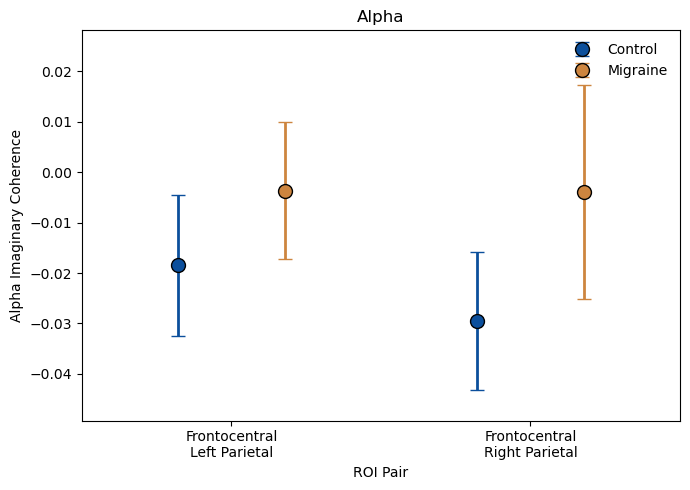

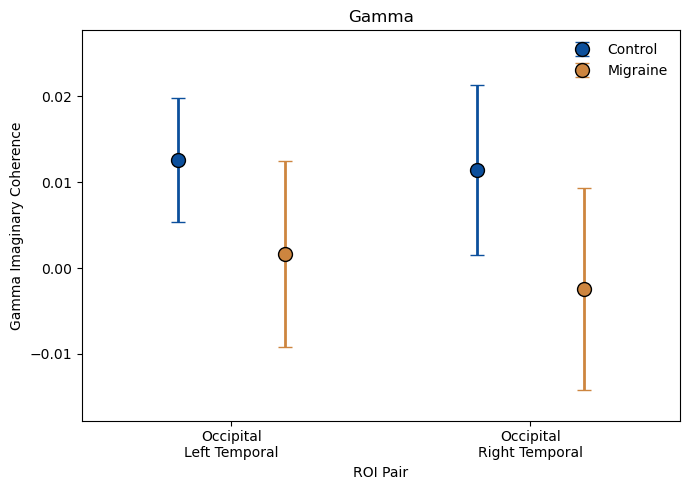

In [16]:
#Plots of covariate-adjusted imaginary coherence

COLORS = {
    "Control": "#0B4F9C",
    "Migraine": "#CD853F"
}

PRETTY_LABELS = {
    "frontocentral_leftparietal": "Frontocentral\nLeft Parietal",
    "frontocentral_rightparietal": "Frontocentral\nRight Parietal",
    "occipital_lefttemporal": "Occipital\nLeft Temporal",
    "occipital_righttemporal": "Occipital\nRight Temporal"
}

DESKTOP = Path.home() / "Desktop"

def plot_connectivity(pair_order, band, ylabel, title):

    adjusted_rows = []

    # Compute covariate-adjusted values

    for pair in pair_order:

        variable = f"{pair}_{band}"

        d = df[
            ["group", "sex", "bdi", "pss", variable]
        ].copy()

        d = d.rename(columns={variable: "connectivity"})

        y = d["connectivity"].astype(float).values
        group = d["group"].astype(float).values
        sex = d["sex"].astype(float).values
        bdi = d["bdi"].astype(float).values
        pss = d["pss"].astype(float).values

        valid = (
            np.isfinite(y)
            & np.isfinite(group)
            & np.isfinite(sex)
            & np.isfinite(bdi)
            & np.isfinite(pss)
        )

        d = d.loc[valid].copy()

        y = y[valid]
        group = group[valid]
        sex = sex[valid]
        bdi = bdi[valid]
        pss = pss[valid]

        #Same full model used for the group comparison:
        #intercept + group + sex + BDI + PSS
        X = np.column_stack([
            np.ones(len(y)),
            group,
            sex,
            bdi,
            pss
        ])

        beta = np.linalg.lstsq(X, y, rcond=None)[0]

        #Evaluate both groups at identical mean covariate values
        mean_sex = sex.mean()
        mean_bdi = bdi.mean()
        mean_pss = pss.mean()

        control_mean = (
            beta[0]
            + beta[1] * 0
            + beta[2] * mean_sex
            + beta[3] * mean_bdi
            + beta[4] * mean_pss
        )

        migraine_mean = (
            beta[0]
            + beta[1] * 1
            + beta[2] * mean_sex
            + beta[3] * mean_bdi
            + beta[4] * mean_pss
        )

        #Preserve participant-level residual variation
        fitted = X @ beta
        residuals = y - fitted

        d["adjusted"] = np.where(
            group == 0,
            control_mean + residuals,
            migraine_mean + residuals
        )

        d["pair"] = pair

        d["group_label"] = np.where(
            d["group"] == 0,
            "Control",
            "Migraine"
        )

        adjusted_rows.append(d)

    plot_df = pd.concat(adjusted_rows, ignore_index=True)

    #Summary statistics for plotting

    summary = (
        plot_df
        .groupby(["pair", "group_label"])
        .agg(
            mean=("adjusted", "mean"),
            sem=("adjusted",
                 lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
            n=("adjusted", "count")
        )
        .reset_index()
    )

    summary["ci95"] = 1.96 * summary["sem"]

    #Determine significant pairs directly from results_df

    significant_pairs = results_df.loc[
        (results_df["band"].astype(str) == band)
        & (results_df["significant_fdr"]),
        "roi_pair"
    ].tolist()

    significant_pairs = [
        pair for pair in significant_pairs
        if pair in pair_order
    ]
    
    # Create point-range plot

    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(pair_order))
    offset = 0.18

    ymin = (
        summary["mean"] - summary["ci95"]
    ).min()

    ymax = (
        summary["mean"] + summary["ci95"]
    ).max()

    for group_label, xpos in zip(
        ["Control", "Migraine"],
        [-offset, offset]
    ):

        means = []
        ci95s = []

        for pair in pair_order:

            row = summary[
                (summary["pair"] == pair)
                & (summary["group_label"] == group_label)
            ]

            means.append(row["mean"].iloc[0])
            ci95s.append(row["ci95"].iloc[0])

        ax.errorbar(
            x + xpos,
            means,
            yerr=ci95s,
            fmt="o",
            markersize=10,
            capsize=5,
            linewidth=2,
            color=COLORS[group_label],
            markerfacecolor=COLORS[group_label],
            markeredgecolor="black",
            label=group_label,
            zorder=3
        )

    #Significance brackets based on corrected FDR results

    y_range = ymax - ymin

    for pair in significant_pairs:

        i = pair_order.index(pair)

        pair_rows = summary[
            summary["pair"] == pair
        ]

        pair_top = (
            pair_rows["mean"] + pair_rows["ci95"]
        ).max()

        bracket_y = pair_top + y_range * 0.06

        ax.plot(
            [
                i - offset,
                i - offset,
                i + offset,
                i + offset
            ],
            [
                bracket_y,
                bracket_y + y_range * 0.02,
                bracket_y + y_range * 0.02,
                bracket_y
            ],
            color="black",
            linewidth=1.5
        )

        ax.text(
            i,
            bracket_y + y_range * 0.03,
            "*",
            ha="center",
            va="bottom",
            fontsize=16,
            fontweight="bold"
        )

    # Formatting

    ax.set_xticks(x)

    ax.set_xticklabels(
        [PRETTY_LABELS[pair] for pair in pair_order]
    )

    ax.set_xlim(-0.5, len(pair_order) - 0.5)

    ax.set_ylim(
        ymin - y_range * 0.10,
        ymax + y_range * 0.18
    )

    ax.set_ylabel(ylabel)
    ax.set_xlabel("ROI Pair")
    ax.set_title(title)

    ax.legend(frameon=False)

    plt.tight_layout()

    # Save once, to Desktop, before showing
    fig.savefig(
        DESKTOP / f"{band}_imcoh_positive.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

#Alpha

plot_connectivity(
    pair_order=[
        "frontocentral_leftparietal",
        "frontocentral_rightparietal"
    ],
    band="alpha",
    ylabel="Alpha Imaginary Coherence",
    title="Alpha"
)

#Gamma

plot_connectivity(
    pair_order=[
        "occipital_lefttemporal",
        "occipital_righttemporal"
    ],
    band="gamma",
    ylabel="Gamma Imaginary Coherence",
    title="Gamma"
)

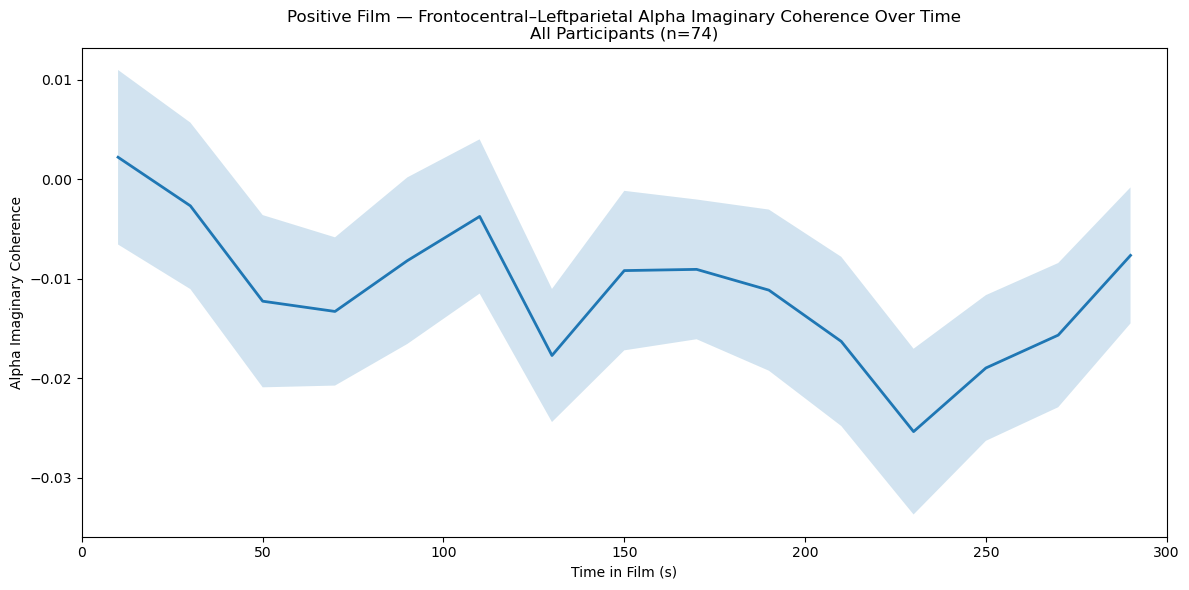

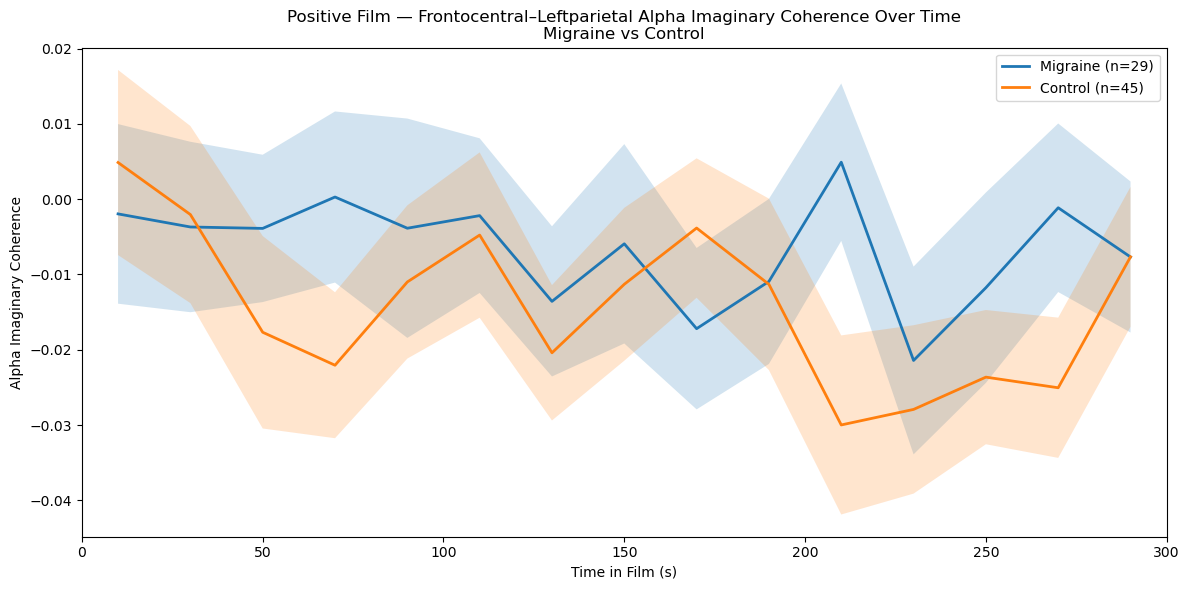

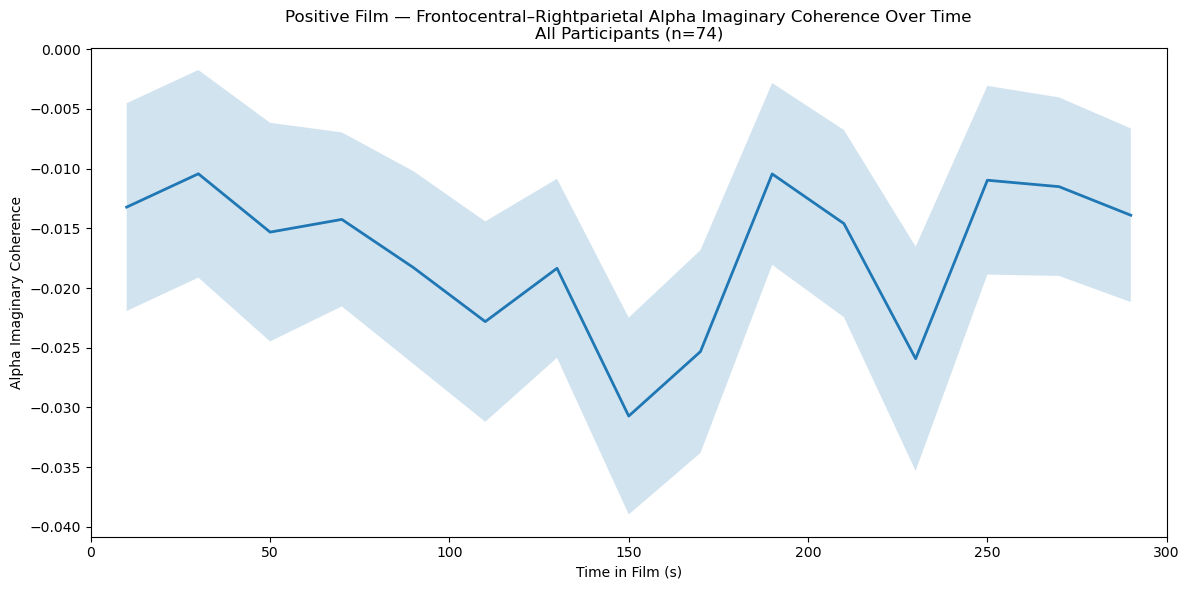

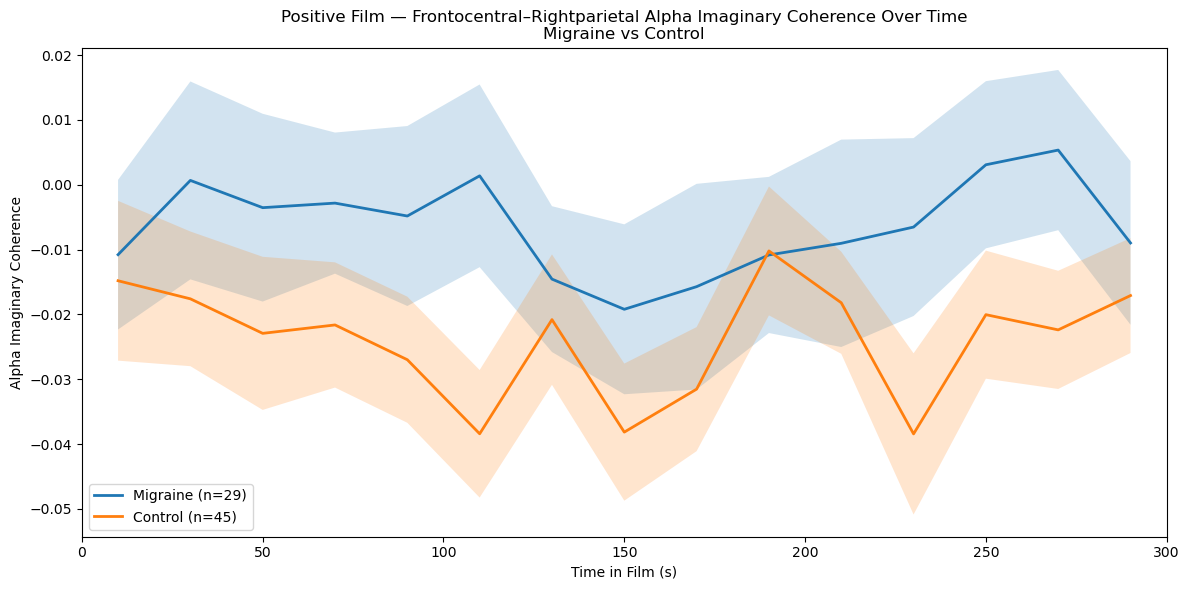

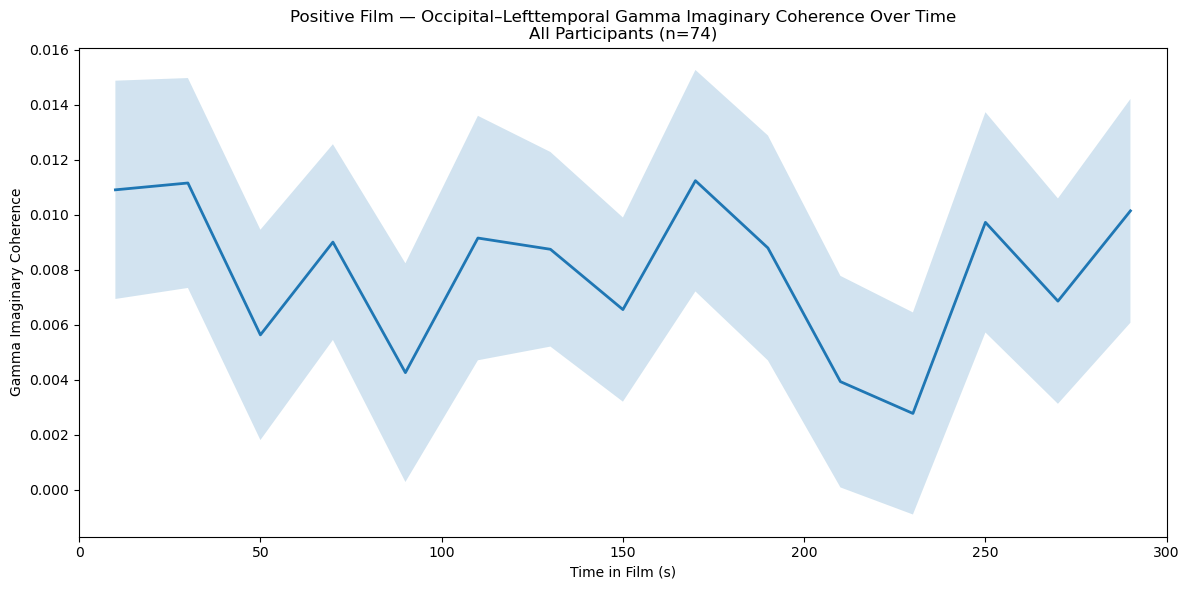

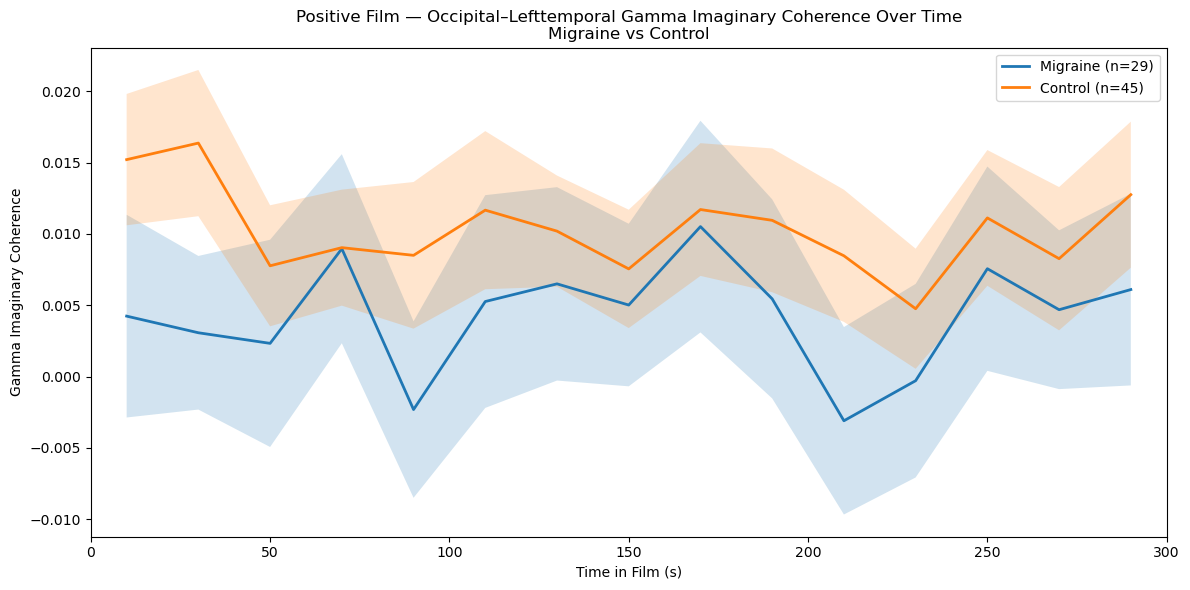

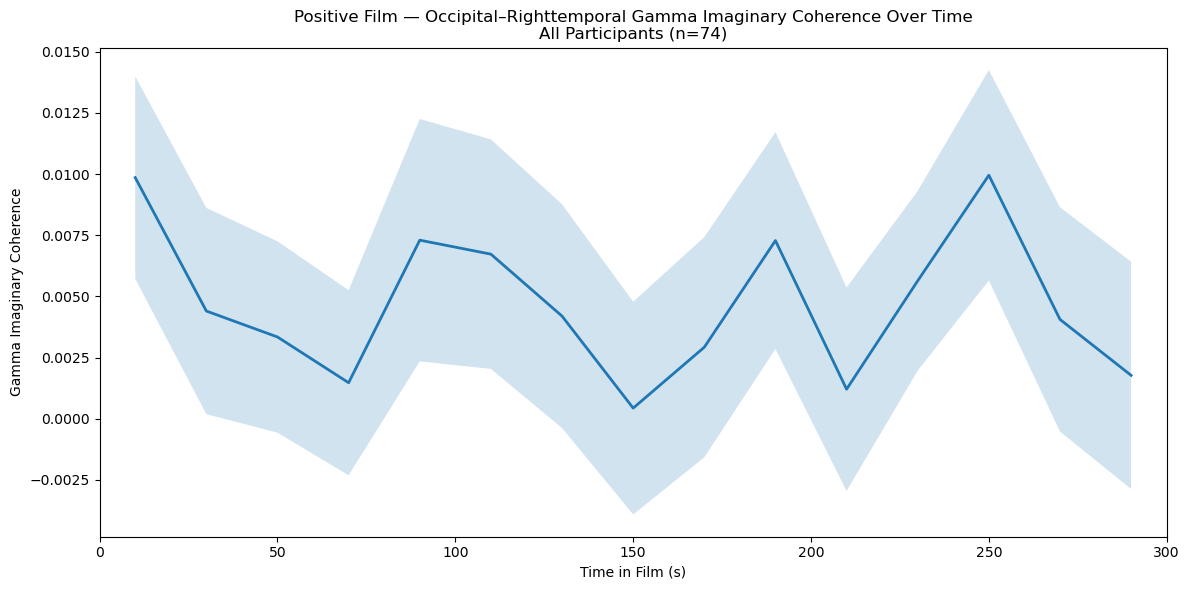

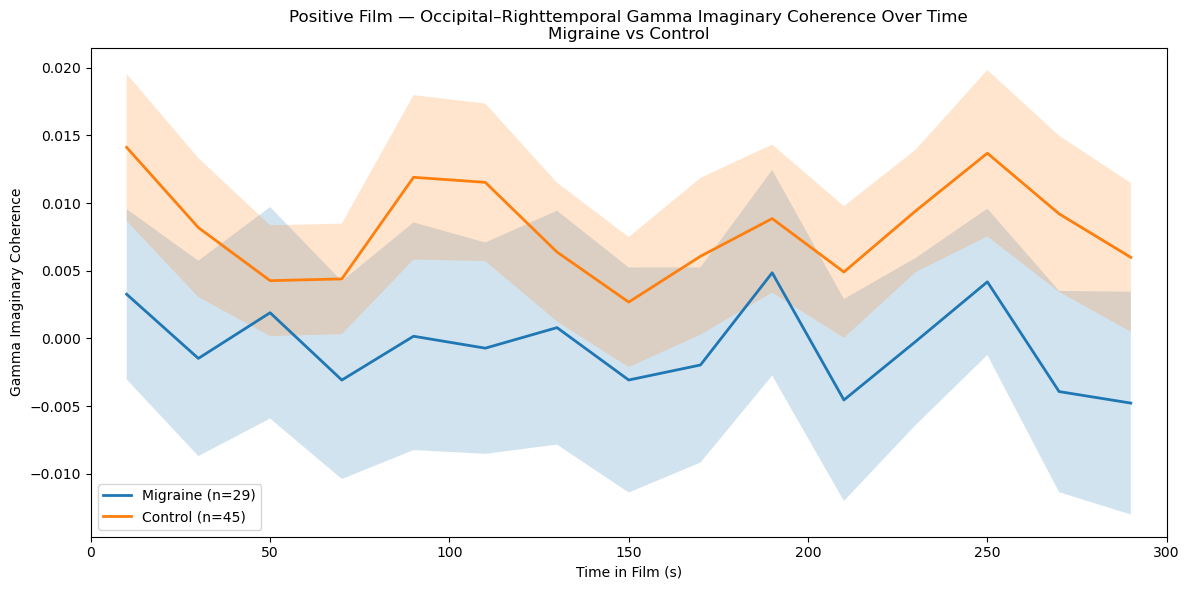

In [18]:
#Imaginary coherence throughout the film
#5 consecutive 4-s epochs = 20s time bins

EPOCHS_PER_BIN = 5
DESKTOP = Path.home() / "Desktop"

TIMECOURSE_TESTS = [
    ("frontocentral", "leftparietal", "alpha"),
    ("frontocentral", "rightparietal", "alpha"),
    ("occipital", "lefttemporal", "gamma"),
    ("occipital", "righttemporal", "gamma"),
]

#Calculate imaginary coherence in each 20s bin

timecourse = {}

for sub_id, indices in subject_indices.items():

    if sub_id not in group_a_subjects and sub_id not in group_b_subjects:
        continue

    epochs = epochs_dict[sub_id]

    n_bins = len(epochs) // EPOCHS_PER_BIN

    subject_values = {
        test: []
        for test in TIMECOURSE_TESTS
    }

    for bin_idx in range(n_bins):

        start = bin_idx * EPOCHS_PER_BIN
        stop = start + EPOCHS_PER_BIN

        conn = spectral_connectivity_epochs(
            data=epochs[start:stop],
            method=CONNECTIVITY_METHOD,
            mode="multitaper",
            sfreq=epochs.info["sfreq"],
            fmin=FMIN,
            fmax=FMAX,
            faverage=True,
            indices=indices,
            mt_adaptive=True,
            n_jobs=1,
            verbose=False,
        )

        connectivity_vals = conn.get_data()

        for roi_a, roi_b, band in TIMECOURSE_TESTS:

            positions = roi_pair_positions[(roi_a, roi_b)]
            band_index = BAND_NAMES.index(band)

            subject_values[(roi_a, roi_b, band)].append(
                connectivity_vals[
                    positions,
                    band_index
                ].mean()
            )

    timecourse[sub_id] = subject_values

#Common time axis

n_common_bins = min(
    len(values[TIMECOURSE_TESTS[0]])
    for values in timecourse.values()
)

time_seconds = (
    np.arange(n_common_bins) * 20 + 10
)

#Plotting function

def plot_timecourse(roi_a, roi_b, band):

    key = (roi_a, roi_b, band)

    migraine = np.array([
        timecourse[sub][key][:n_common_bins]
        for sub in group_a_subjects
        if sub in timecourse
    ])

    control = np.array([
        timecourse[sub][key][:n_common_bins]
        for sub in group_b_subjects
        if sub in timecourse
    ])

    all_participants = np.vstack([
        migraine,
        control
    ])

    #All participants

    mean = all_participants.mean(axis=0)

    sem = (
        all_participants.std(axis=0, ddof=1)
        / np.sqrt(all_participants.shape[0])
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        time_seconds,
        mean,
        linewidth=2
    )

    plt.fill_between(
        time_seconds,
        mean - sem,
        mean + sem,
        alpha=0.2
    )

    plt.xlabel("Time in Film (s)")
    plt.ylabel(
        f"{band.capitalize()} Imaginary Coherence"
    )

    plt.title(
        f"Positive Film — "
        f"{roi_a.replace('_', ' ').title()}–"
        f"{roi_b.replace('_', ' ').title()} "
        f"{band.capitalize()} Imaginary Coherence Over Time\n"
        f"All Participants (n={len(all_participants)})"
    )

    plt.xlim(0, n_common_bins * 20)
    plt.tight_layout()

    plt.savefig(
        DESKTOP /
        f"Positive_{band}_ImCoH_"
        f"{roi_a}_{roi_b}_AllParticipants.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    #Migraine vs control

    migraine_mean = migraine.mean(axis=0)
    control_mean = control.mean(axis=0)

    migraine_sem = (
        migraine.std(axis=0, ddof=1)
        / np.sqrt(migraine.shape[0])
    )

    control_sem = (
        control.std(axis=0, ddof=1)
        / np.sqrt(control.shape[0])
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        time_seconds,
        migraine_mean,
        linewidth=2,
        label=f"Migraine (n={len(migraine)})"
    )

    plt.fill_between(
        time_seconds,
        migraine_mean - migraine_sem,
        migraine_mean + migraine_sem,
        alpha=0.2
    )

    plt.plot(
        time_seconds,
        control_mean,
        linewidth=2,
        label=f"Control (n={len(control)})"
    )

    plt.fill_between(
        time_seconds,
        control_mean - control_sem,
        control_mean + control_sem,
        alpha=0.2
    )

    plt.xlabel("Time in Film (s)")
    plt.ylabel(
        f"{band.capitalize()} Imaginary Coherence"
    )

    plt.title(
        f"Positive Film — "
        f"{roi_a.replace('_', ' ').title()}–"
        f"{roi_b.replace('_', ' ').title()} "
        f"{band.capitalize()} Imaginary Coherence Over Time\n"
        f"Migraine vs Control"
    )

    plt.xlim(0, n_common_bins * 20)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        DESKTOP /
        f"Positive_{band}_ImCoH_"
        f"{roi_a}_{roi_b}_MigraineVsControl.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

#Create time course plots

for roi_a, roi_b, band in TIMECOURSE_TESTS:
    plot_timecourse(
        roi_a,
        roi_b,
        band
    )